# Import libraries

In [2]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [3]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [4]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def eos(z, w):
    return w[0] + w[1]*z/(1+z)

def Friedmann_eq2(z, theta):
    omega_M, H0, w0, w1 = theta
    w = eos(z, [w0, w1])
    omega_DE = 1 - omega_M
    H2 = (H0**2)*(omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)))
    return H2

def integrand(z, theta):
    return c/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def dist_modulus(z, theta):
    rc = co_moving_dist(z, theta)
    dl = (1+z)*rc
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

# Load the data

In [5]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [6]:
H0_prior = 69.02
H0_stdev_prior = 2.08*10
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056
omega_M_prior = 0.31
omega_M_stdev_prior = 0.04*10

def log_prior(theta, z):
    omega_M, H0, w0, w1 = theta
    H2 = Friedmann_eq2(z, theta)
    if not (np.all(H2>0) and -3<w0<3 and 20<H0<100 and -20<w1<10 and 0<omega_M<1):
        return -np.inf
    return 0.0

nparams = 4
nwalkers = 50
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(0.2, 0.4)
    pos[i][1] = np.random.uniform(20, 100)
    pos[i][2] = np.random.uniform(-3,1)
    pos[i][3] = np.random.uniform(-3,2)
    

# Likelihood function

In [7]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [8]:
nsteps = 1000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

 24%|██▎       | 1184/5000 [07:51<17:16,  3.68it/s]  

emcee: Exception while calling your likelihood function:
  params: [ 5.35686701e-01  7.13235286e+01 -2.44447439e-02 -7.33402461e+00]
  args: (array([1.22000e-03, 1.22000e-03, 2.56000e-03, ..., 1.80119e+00,
       1.91165e+00, 2.26137e+00]), array([28.9987, 29.0559, 30.7233, ..., 45.4865, 45.4233, 46.1828]), array([[ 3.35405114e+01, -5.68645204e+00, -1.07870284e-01, ...,
         1.44562418e-02,  1.73619146e-02,  6.56463541e-02],
       [-5.68645201e+00,  3.26679150e+01,  6.27809019e-01, ...,
         5.90524514e-02,  5.86751704e-02,  9.18237282e-02],
       [-1.07870328e-01,  6.27808965e-01,  5.66302667e+01, ...,
         4.04987268e-02,  6.08045796e-02,  1.44339360e-01],
       ...,
       [ 1.44562147e-02,  5.90524254e-02,  4.04987139e-02, ...,
         2.64804296e+01, -2.56390503e-01, -5.18344051e-01],
       [ 1.73618976e-02,  5.86751545e-02,  6.08045714e-02, ...,
        -2.56390503e-01,  1.63294720e+01, -4.65796138e-01],
       [ 6.56463083e-02,  9.18236857e-02,  1.44339335e-01, 

Traceback (most recent call last):
  File "C:\Users\milan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_14644\3231594283.py", line 13, in log_probability
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\milan\AppData\Local\Temp\ipykernel_14644\3231594283.py", line 4, in log_likelihood
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
 24%|██▎       | 1184/5000 [07:52<25:22,  2.51it/s]


KeyboardInterrupt: 

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 24;
tau: [100.6124221   31.87043952  67.4771086   83.06116415]

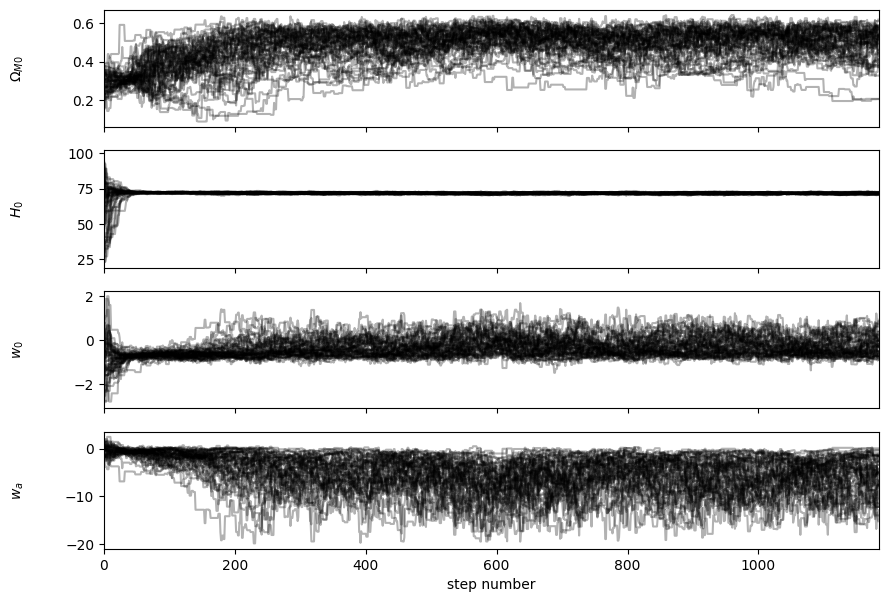

In [9]:
#sampler.run_mcmc(None, 4500, progress = True)
ndiscard = 8 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{M0}$", "$H_{0}$", "$w_{0}$", "$w_{a}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
#plt.savefig("walkers_CPL_CDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

# Covariance plots

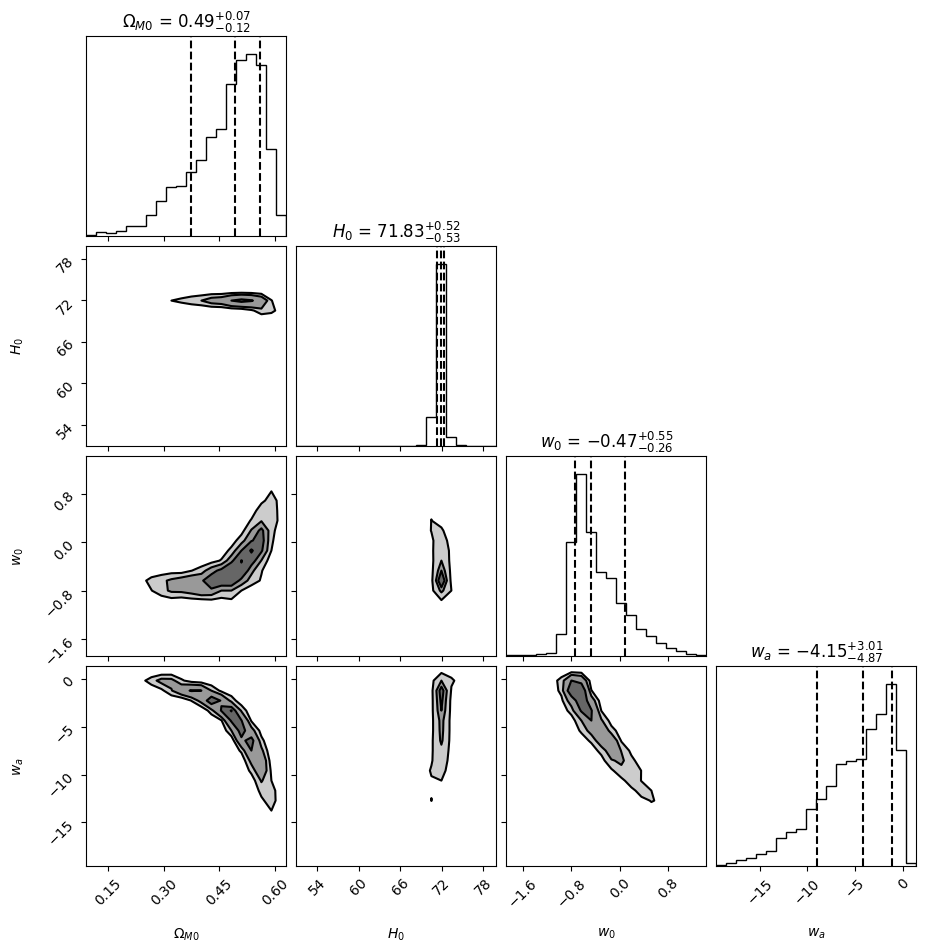

In [10]:

fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}, plot_datapoints=False, fill_contours = True
)
#plt.savefig("corner_CPL_CDM.png")

In [ ]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: -0.06237479351851676 + 0.033591067089133037 - 0.03519644863210971
$Ω_{Λ0}$: 0.6885654274691756 + 0.005337126854226493 - 0.005593448384514255
$H_{0}$: 68.14028916563848 + 2.176652163778485 - 2.0541641204174823
$w_{0}$: -0.7030597684035762 + 0.1294141359549419 - 0.13137557551896895
$w_{1}$: -1.144450987828366 + 0.5436705544675375 - 0.654331327922145


In [ ]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

chi-squared: 1746.9054824115804


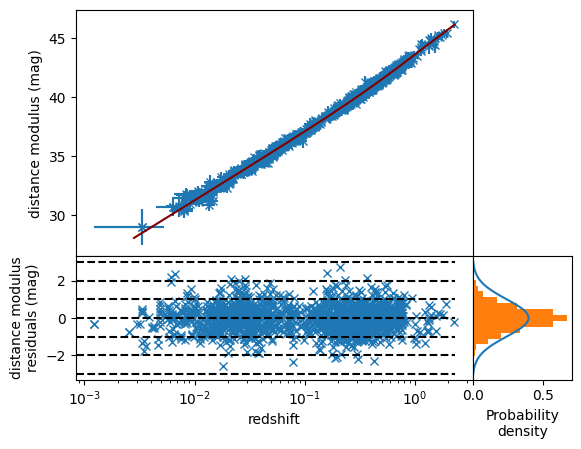

BIC: 1784.1003403735597


In [ ]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)

fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 20))
#plt.savefig("plot_aCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")